# Diabetes Prediction using Machine Learning

## Problem Statement
The goal of this project is to predict whether a patient has diabetes based on medical features such as glucose level, BMI, insulin, etc.

## Dataset
This dataset is the Pima Indians Diabetes Dataset, commonly used for binary classification problems.

## Objective
To build and evaluate machine learning models and compare their performance.

In [3]:
from sklearn.datasets import load_diabetes

## Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to understand feature distributions and relationships with the target variable.

In [4]:
dataset = load_diabetes()

In [ ]:
dataset
# data is the independent features and the target is dependent features

In [ ]:
print(dataset['DESCR'])

## Data Preprocessing

- Handling invalid/missing values
- Feature scaling
- Splitting data into training and testing sets

In [5]:
import pandas as pd
df_diabetes = pd.DataFrame(dataset.data, columns=['age','sex','bmi','bp', 's1', 's2', 's3', 's4', 's5', 's6'])

In [6]:
df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [7]:
X = df_diabetes
y = dataset['target']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10) 

In [9]:
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207
389,-0.005515,0.050680,0.001339,-0.084856,-0.011201,-0.016658,0.048640,-0.039493,-0.041176,-0.088062
121,0.063504,-0.044642,0.017506,0.021872,0.008063,0.021546,-0.036038,0.034309,0.019907,0.011349
195,0.027178,0.050680,0.025051,0.014987,0.025950,0.048477,-0.039719,0.034309,0.007838,0.023775
69,0.016281,-0.044642,-0.046085,-0.005670,-0.075870,-0.061438,-0.013948,-0.039493,-0.051404,0.019633


In [10]:
## Check Correlation 
X_train.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.197408,0.198359,0.394903,0.238375,0.192920,-0.128403,0.227110,0.314151,0.351570
sex,0.197408,1.000000,0.108261,0.221914,0.057674,0.180315,-0.379464,0.324882,0.150956,0.193322
bmi,0.198359,0.108261,1.000000,0.356324,0.226047,0.248146,-0.395021,0.412826,0.435505,0.358273
bp,0.394903,0.221914,0.356324,1.000000,0.238295,0.165632,-0.192505,0.249141,0.420236,0.368882
s1,0.238375,0.057674,0.226047,0.238295,1.000000,0.872781,0.006313,0.559626,0.566312,0.356280
s2,0.192920,0.180315,0.248146,0.165632,0.872781,1.000000,-0.265114,0.684840,0.325759,0.315890
s3,-0.128403,-0.379464,-0.395021,-0.192505,0.006313,-0.265114,1.000000,-0.754616,-0.370523,-0.297055
s4,0.227110,0.324882,0.412826,0.249141,0.559626,0.684840,-0.754616,1.000000,0.609983,0.436311
s5,0.314151,0.150956,0.435505,0.420236,0.566312,0.325759,-0.370523,0.609983,1.000000,0.490970
s6,0.351570,0.193322,0.358273,0.368882,0.356280,0.315890,-0.297055,0.436311,0.490970,1.000000


<Axes: >

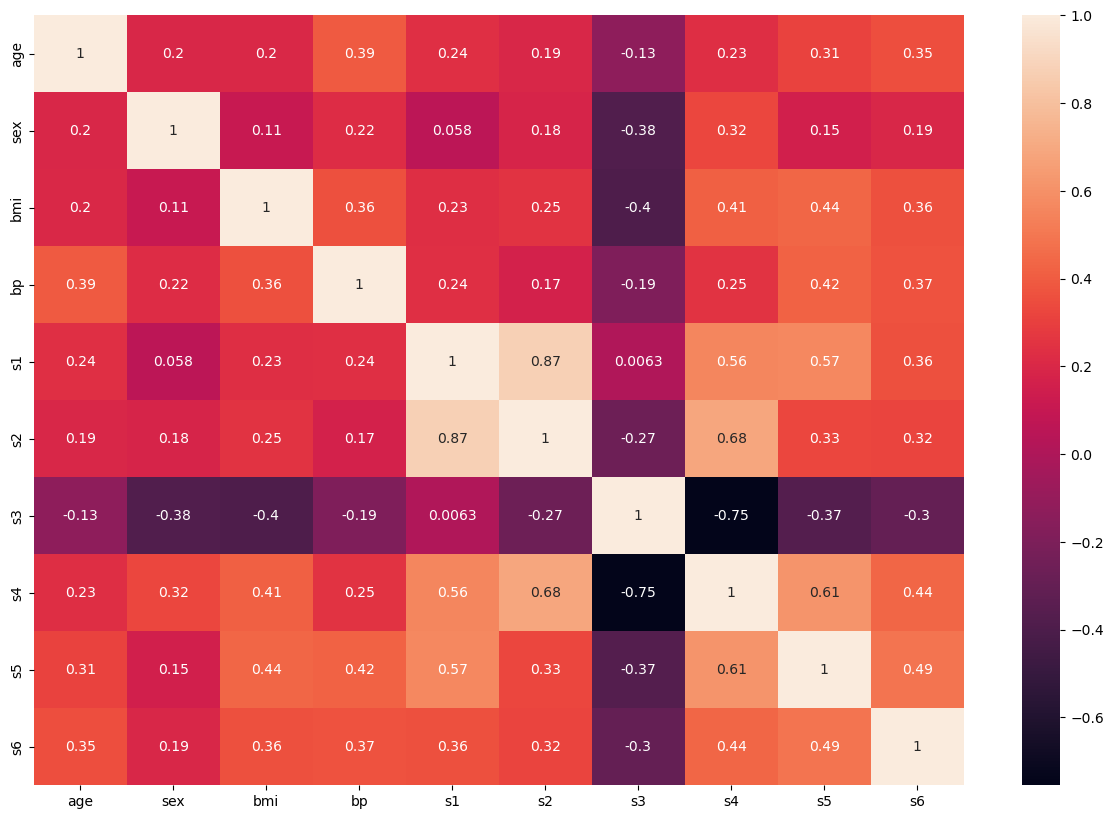

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(), annot=True)

In [12]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Hyperparameter Tuning

In [13]:
param={
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'splitter': ['best', 'random'],
    'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [14]:
from sklearn.model_selection import GridSearchCV

In [15]:
regressor = DecisionTreeRegressor()

In [16]:
grid = GridSearchCV(regressor, param_grid=param, cv=5, scoring='neg_mean_squared_error')

In [17]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'absolute_error'


In [23]:
grid.best_params_

{'criterion': 'absolute_error',
 'max_depth': 2,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [24]:
# Predictions
y_pred = grid.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.33220272667493567
50.50375939849624
4225.601503759399


In [27]:
# Now work on the best selected model
selectedmodel = DecisionTreeRegressor(criterion='absolute_error', max_depth=2, max_features='sqrt', splitter='best')

In [28]:
selectedmodel.fit(X_train, y_train)

,criterion,'absolute_error'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.5, 0.8333333333333334, 'x[3] <= 0.003\nabsolute_error = 63.683\nsamples = 309\nvalue = 140.0'),
 Text(0.25, 0.5, 'x[7] <= 0.02\nabsolute_error = 50.472\nsamples = 176\nvalue = 110.5'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'absolute_error = 40.612\nsamples = 129\nvalue = 96.0'),
 Text(0.375, 0.16666666666666666, 'absolute_error = 58.255\nsamples = 47\nvalue = 168.0'),
 Text(0.75, 0.5, 'x[9] <= 0.034\nabsolute_error = 63.714\nsamples = 133\nvalue = 189.0'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'absolute_error = 58.966\nsamples = 88\nvalue = 170.5'),
 Text(0.875, 0.16666666666666666, 'absolute_error = 58.044\nsamples = 45\nvalue = 246.0')]

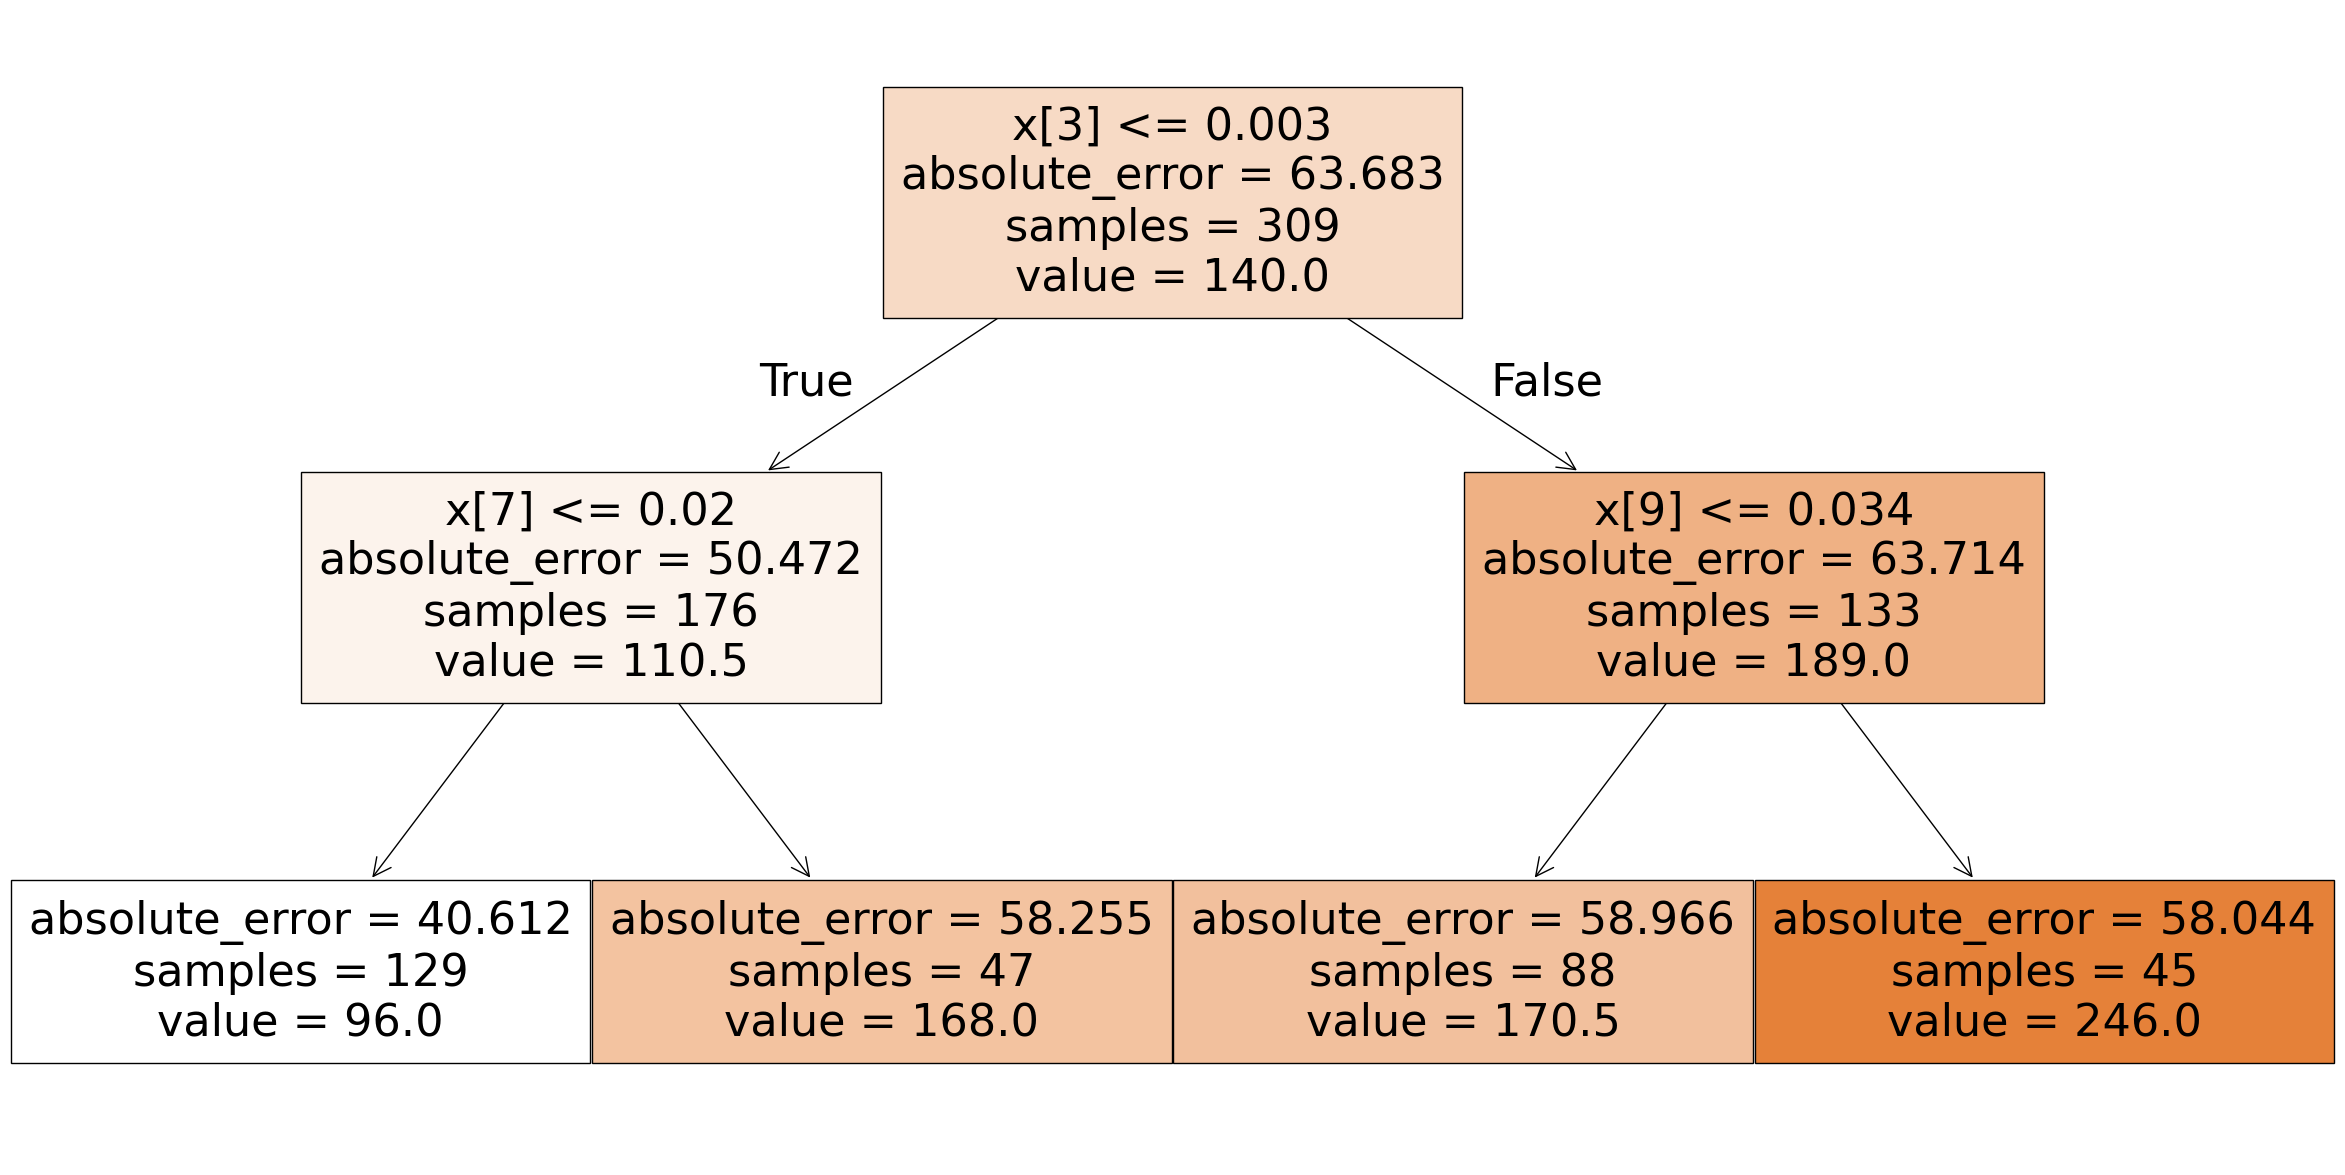

In [29]:
# Visualize the DT
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(30, 15))
tree.plot_tree(selectedmodel, filled=True)